BDA ASSIGNMENT 2


Q1 : Build a classification model with spark with a dataset




Environment setup

In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Test").getOrCreate()
spark

In [ ]:
# Download the CSV file locally
!wget -q https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv

Load Dataset

In [ ]:
df = spark.read.csv(
    "iris.csv",  # Read from the locally downloaded file
    header=True,
    inferSchema=True
)

df.show(5)

+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| setosa|
|         4.9|        3.0|         1.4|        0.2| setosa|
|         4.7|        3.2|         1.3|        0.2| setosa|
|         4.6|        3.1|         1.5|        0.2| setosa|
|         5.0|        3.6|         1.4|        0.2| setosa|
+------------+-----------+------------+-----------+-------+
only showing top 5 rows


Data Preprocessing

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["sepal_length", "sepal_width", "petal_length", "petal_width"],
    outputCol="features"
)

data = assembler.transform(df)

In [ ]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="species", outputCol="label")
data = indexer.fit(data).transform(data)

data.select("features", "label").show(5)

+-----------------+-----+
|         features|label|
+-----------------+-----+
|[5.1,3.5,1.4,0.2]|  0.0|
|[4.9,3.0,1.4,0.2]|  0.0|
|[4.7,3.2,1.3,0.2]|  0.0|
|[4.6,3.1,1.5,0.2]|  0.0|
|[5.0,3.6,1.4,0.2]|  0.0|
+-----------------+-----+
only showing top 5 rows


Train and test split

In [ ]:
train, test = data.randomSplit([0.7, 0.3])

Train Model

In [ ]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features", labelCol="label")
model = lr.fit(train)

Make Prediction

In [ ]:
predictions = model.transform(test)
predictions.select("features", "label", "prediction").show()

+-----------------+-----+----------+
|         features|label|prediction|
+-----------------+-----+----------+
|[4.3,3.0,1.1,0.1]|  0.0|       0.0|
|[4.4,3.2,1.3,0.2]|  0.0|       0.0|
|[4.6,3.1,1.5,0.2]|  0.0|       0.0|
|[4.6,3.6,1.0,0.2]|  0.0|       0.0|
|[4.8,3.4,1.9,0.2]|  0.0|       0.0|
|[4.9,2.4,3.3,1.0]|  1.0|       1.0|
|[4.9,2.5,4.5,1.7]|  2.0|       2.0|
|[4.9,3.0,1.4,0.2]|  0.0|       0.0|
|[4.9,3.1,1.5,0.1]|  0.0|       0.0|
|[4.9,3.6,1.4,0.1]|  0.0|       0.0|
|[5.0,2.0,3.5,1.0]|  1.0|       1.0|
|[5.0,3.0,1.6,0.2]|  0.0|       0.0|
|[5.0,3.5,1.3,0.3]|  0.0|       0.0|
|[5.0,3.5,1.6,0.6]|  0.0|       0.0|
|[5.1,2.5,3.0,1.1]|  1.0|       1.0|
|[5.1,3.7,1.5,0.4]|  0.0|       0.0|
|[5.1,3.8,1.6,0.2]|  0.0|       0.0|
|[5.4,3.7,1.5,0.2]|  0.0|       0.0|
|[5.5,2.4,3.7,1.0]|  1.0|       1.0|
|[5.6,2.5,3.9,1.1]|  1.0|       1.0|
+-----------------+-----+----------+
only showing top 20 rows


evaluate model


In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9591836734693877


Confusion Matrix

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

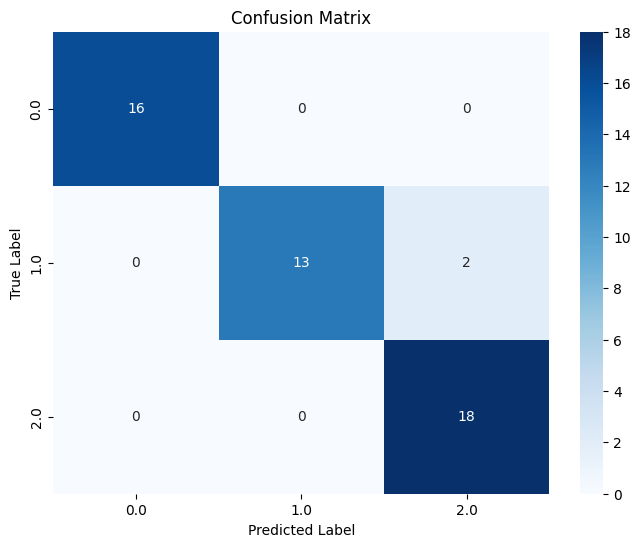

In [ ]:
predictions_pd = predictions.select("label", "prediction").toPandas()

cm = confusion_matrix(predictions_pd["label"], predictions_pd["prediction"])

class_labels = sorted(predictions_pd["label"].unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()